In [1]:
# Import necessary libraries for data analysis and visualization
import numpy as np  # Import numpy for numerical operations
import pandas as pd  # Import pandas for data manipulation and analysis
import matplotlib.pyplot as plt # Import matplotlib.pyplot for data visualization

In [2]:
# Importing the train_test_split function from scikit-learn, which is used to split data into training and testing sets.
from sklearn.model_selection import train_test_split

# Importing SimpleImputer from scikit-learn, which is used for handling missing data by replacing it with a specific value (e.g., mean, median, etc.).
from sklearn.impute import SimpleImputer

# Importing ColumnTransformer from scikit-learn, which is a tool for applying different preprocessing steps to different columns of a dataset.
from sklearn.compose import ColumnTransformer

In [3]:
# Load the dataset from the CSV file
df = pd.read_csv('titanic_toy.csv')

In [4]:
# Display the first 5 rows of the dataframe
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
# Calling the 'info()' method on the DataFrame 'df' to get a concise summary of the dataset.

# The 'info()' method provides the following details about the DataFrame:
# 1. The total number of entries (rows) in the DataFrame.
# 2. The number of non-null values in each column.
# 3. The data type of each column (e.g., int64, float64, object).
# 4. The memory usage of the DataFrame.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
# Calculate the percentage of missing values for each column
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [7]:
# Dropping the 'Survived' column from the DataFrame 'df' to create the feature set 'X'.
# 'X' will contain all columns except 'Survived', which is assumed to be the target variable.
X = df.drop(columns=['Survived'])

# Extracting the target variable 'Survived' from the DataFrame 'df' to create the label set 'y'.
# 'y' will be a Series containing the values of the 'Survived' column.
y = df['Survived']

In [8]:
# Splitting the dataset into training and testing sets using train_test_split from scikit-learn.
# X_train and X_test are the feature sets for the training and testing datasets, respectively.
# y_train and y_test are the corresponding target values (labels) for training and testing.
# - test_size=0.2 means 20% of the data will be used for testing, and 80% will be used for training.
# - random_state=2 ensures reproducibility of the split by setting a fixed seed for the random number generator.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [9]:
# Checking the shape of the training dataset 'X_train'.
# The 'shape' attribute returns a tuple with the number of rows and columns in the DataFrame (or NumPy array).
# - The first value represents the number of rows (samples).
# - The second value represents the number of columns (features).
print(X_train.shape)

# Checking the shape of the testing dataset 'X_test'.
# The 'shape' attribute provides the dimensions of 'X_test', just like for 'X_train'.
# It tells you how many samples and features are in the testing data.
print(X_test.shape)

(712, 3)
(179, 3)


In [10]:
# Calculate the percentage of missing values for X_train
X_train.isnull().mean() * 100

Age       20.786517
Fare       5.056180
Family     0.000000
dtype: float64

In [11]:
# Calculate the mean of the 'Age' column in the training dataset 'X_train'.
# The 'mean()' method computes the average value of the specified column ('Age') by summing all values and dividing by the number of non-null values.
mean_age = X_train['Age'].mean()

# Calculate the median of the 'Age' column in the training dataset 'X_train'.
# The 'median()' method finds the middle value in the sorted list of 'Age' values.
# If the number of values is even, it returns the average of the two middle values.
median_age = X_train['Age'].median()

# Calculate the mean of the 'Fare' column in the training dataset 'X_train'.
# Similar to 'Age', the 'mean()' method calculates the average of all values in 'Fare'.
mean_fare = X_train['Fare'].mean()

# Calculate the median of the 'Fare' column in the training dataset 'X_train'.
# The 'median()' method gives the middle value of the sorted 'Fare' values.
median_fare = X_train['Fare'].median()

In [12]:
# Fill missing values in the 'Age' column with the calculated median value
# This creates a new column 'Age_median' where missing values in 'Age' are replaced by the median age.
X_train['Age_median'] = X_train['Age'].fillna(median_age)

# Fill missing values in the 'Age' column with the calculated mean value
# This creates a new column 'Age_mean' where missing values in 'Age' are replaced by the mean age.
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

# Fill missing values in the 'Fare' column with the calculated median value
# This creates a new column 'Fare_median' where missing values in 'Fare' are replaced by the median fare.
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

# Fill missing values in the 'Fare' column with the calculated mean value
# This creates a new column 'Fare_mean' where missing values in 'Fare' are replaced by the mean fare.
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [13]:
# Display 5 sample record of X_train
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
136,19.0,26.2833,2,19.0,19.0,26.2833,26.2833
600,24.0,27.0000,3,24.0,24.0,27.0000,27.0000
787,8.0,29.1250,5,8.0,8.0,29.1250,29.1250
634,9.0,27.9000,5,9.0,9.0,27.9000,27.9000
34,28.0,82.1708,1,28.0,28.0,82.1708,82.1708


In [14]:
# Print the variance of the original 'Age' variable
# The 'var()' method calculates the variance of the 'Age' column in the training dataset 'X_train'.
# Variance measures how far the values in a dataset are spread out from the mean. 
# A higher variance indicates greater dispersion in the data.
print('Original Age variable variance: ', X_train['Age'].var())

# Print the variance of the 'Age' variable after median imputation
# After filling missing values with the median (creating the 'Age_median' column), 
# this shows how the variance has changed compared to the original 'Age' column.
print('Age Variance after median imputation: ', X_train['Age_median'].var())

# Print the variance of the 'Age' variable after mean imputation
# Similarly, this shows how the variance changes after filling missing values with the mean.
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

# Print the variance of the original 'Fare' variable
# This calculates the variance of the 'Fare' column in the original dataset 'X_train'.
print('Original Fare variable variance: ', X_train['Fare'].var())

# Print the variance of the 'Fare' variable after median imputation
# This shows how the variance changes after replacing missing 'Fare' values with the median.
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())

# Print the variance of the 'Fare' variable after mean imputation
# This shows the variance of the 'Fare' column after filling missing values with the mean.
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.2385256705547


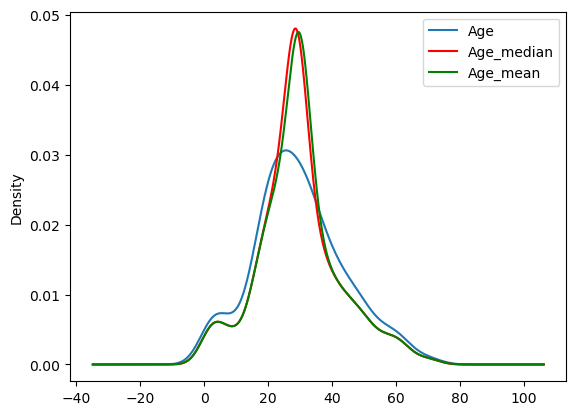

In [15]:
# Create a new figure for the plot
fig = plt.figure()

# Add a subplot to the figure. The parameter '111' means 1 row, 1 column, first plot.
ax = fig.add_subplot(111)

# Plot the Kernel Density Estimate (KDE) of the original 'Age' variable
# KDE plots show the distribution of a continuous variable. 
# This line will display the original 'Age' distribution in the dataset.
X_train['Age'].plot(kind='kde', ax=ax)

# Plot the KDE of the 'Age' variable after median imputation
# This shows how the distribution of 'Age' looks after missing values are filled with the median.
# The line will be in red to distinguish it from the original 'Age' plot.
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# Plot the KDE of the 'Age' variable after mean imputation
# This shows how the distribution of 'Age' looks after missing values are filled with the mean.
# The line will be in green to distinguish it from both the original 'Age' and median-imputed version.
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# Add legends to the plot to label each distribution
# 'ax.get_legend_handles_labels()' returns the lines and labels that are shown in the legend.
lines, labels = ax.get_legend_handles_labels()

# Adding a title to the graph
ax.set_title('Comparison of Age Distributions with Different Imputation Strategies')

# Show the legend in the 'best' location (which is automatically determined by Matplotlib)
ax.legend(lines, labels, loc='best')

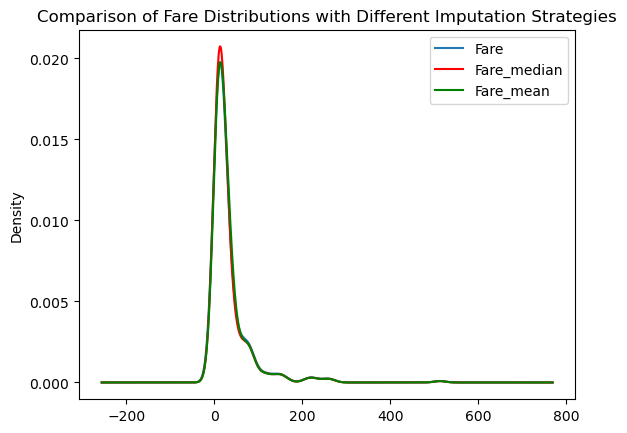

In [16]:
# Create a new figure for the plot
fig = plt.figure()

# Add a subplot to the figure. The parameter '111' means 1 row, 1 column, first plot.
ax = fig.add_subplot(111)

# Plot the Kernel Density Estimate (KDE) of the original 'Fare' variable
# KDE plots show the distribution of a continuous variable. 
# This line will display the original 'Fare' distribution in the dataset.
X_train['Fare'].plot(kind='kde', ax=ax)

# Plot the KDE of the 'Fare' variable after median imputation
# This shows how the distribution of 'Fare' looks after missing values are filled with the median.
# The line will be in red to distinguish it from the original 'Fare' plot.
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# Plot the KDE of the 'Fare' variable after mean imputation
# This shows how the distribution of 'Fare' looks after missing values are filled with the mean.
# The line will be in green to distinguish it from both the original 'Fare' and median-imputed version.
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# Adding a title to the graph
# The 'set_title()' method is used to add a descriptive title to the plot.
ax.set_title('Comparison of Fare Distributions with Different Imputation Strategies')

# Add legends to the plot to label each distribution
# 'ax.get_legend_handles_labels()' returns the lines and labels that are shown in the legend.
lines, labels = ax.get_legend_handles_labels()

# Show the legend in the 'best' location (which is automatically determined by Matplotlib)
ax.legend(lines, labels, loc='best')

In [17]:
# Calculating the covariance matrix for the training dataset 'X_train'.
# The covariance matrix shows the covariance (relationship) between each pair of features (columns) in the dataset.

# - Covariance measures how much two variables change together.
# - A positive covariance indicates that both variables tend to increase or decrease together.
# - A negative covariance indicates that as one variable increases, the other tends to decrease.
# - A covariance of 0 suggests no linear relationship between the variables.

# The result of X_train.cov() is a DataFrame where:
# - Rows and columns represent the features in 'X_train'.
# - Each cell represents the covariance between the corresponding pair of features.
covariance_matrix = X_train.cov()

# You can print the covariance matrix to view it:
print(covariance_matrix)

                    Age         Fare     Family  Age_median    Age_mean  \
Age          204.349513    70.719262  -6.498901  204.349513  204.349513   
Fare          70.719262  2448.197914  17.258917   57.957599   55.603719   
Family        -6.498901    17.258917   2.735252   -5.112563   -5.146106   
Age_median   204.349513    57.957599  -5.112563  161.989566  161.812625   
Age_mean     204.349513    55.603719  -5.146106  161.812625  161.812625   
Fare_median   64.858859  2448.197914  16.476305   53.553455   51.358000   
Fare_mean     66.665205  2448.197914  16.385048   55.023037   52.788341   

             Fare_median    Fare_mean  
Age            64.858859    66.665205  
Fare         2448.197914  2448.197914  
Family         16.476305    16.385048  
Age_median     53.553455    55.023037  
Age_mean       51.358000    52.788341  
Fare_median  2340.091022  2324.238526  
Fare_mean    2324.238526  2324.238526  


In [18]:
# Calculating the correlation matrix for the training dataset 'X_train'.
# The correlation matrix shows the Pearson correlation coefficients between each pair of features (columns) in the dataset.

# - Correlation measures the strength and direction of the linear relationship between two variables.
# - Values range from -1 to 1:
#   - A value close to 1 indicates a strong positive correlation (as one variable increases, the other also increases).
#   - A value close to -1 indicates a strong negative correlation (as one variable increases, the other decreases).
#   - A value close to 0 indicates little to no linear relationship between the variables.

# The result of X_train.corr() is a DataFrame where:
# - Rows and columns represent the features in 'X_train'.
# - Each cell represents the correlation coefficient between the corresponding pair of features.
correlation_matrix = X_train.corr()

# You can print the correlation matrix to view it:
print(correlation_matrix)

                  Age      Fare    Family  Age_median  Age_mean  Fare_median  \
Age          1.000000  0.092644 -0.299113    1.000000  1.000000     0.087356   
Fare         0.092644  1.000000  0.208268    0.091757  0.088069     1.000000   
Family      -0.299113  0.208268  1.000000   -0.242883 -0.244610     0.205942   
Age_median   1.000000  0.091757 -0.242883    1.000000  0.999454     0.086982   
Age_mean     1.000000  0.088069 -0.244610    0.999454  1.000000     0.083461   
Fare_median  0.087356  1.000000  0.205942    0.086982  0.083461     1.000000   
Fare_mean    0.090156  1.000000  0.205499    0.089673  0.086078     0.996607   

             Fare_mean  
Age           0.090156  
Fare          1.000000  
Family        0.205499  
Age_median    0.089673  
Age_mean      0.086078  
Fare_median   0.996607  
Fare_mean     1.000000  


<Axes: >

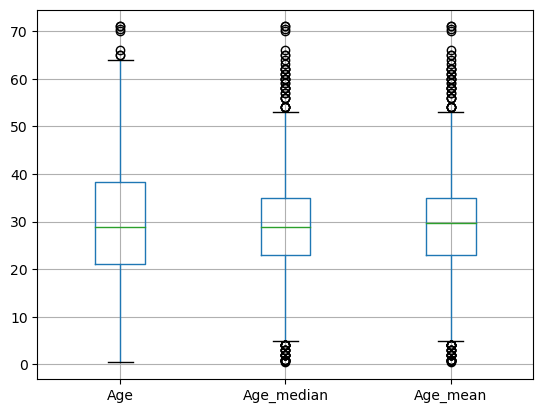

In [19]:
# Create a boxplot for the columns 'Age', 'Age_median', and 'Age_mean'
# A boxplot provides a summary of a set of data values, showing the median, quartiles, and potential outliers.
# The code will generate a boxplot comparing the distribution of the original 'Age' values 
# with those that have been imputed using the median and mean.
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

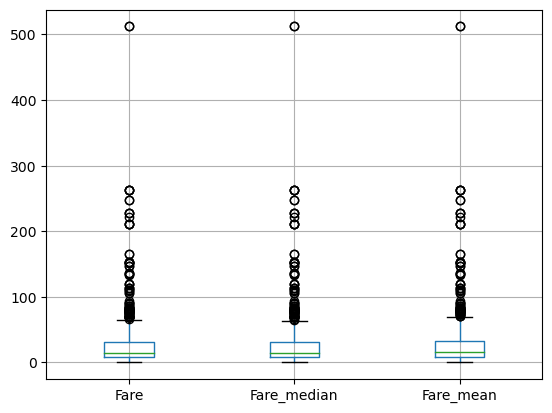

In [20]:
# Create a boxplot for the columns 'Fare', 'Fare_median', and 'Fare_mean'
# This will display the distribution of the original 'Fare' variable as well as the distributions
# of 'Fare' after imputation using the median and the mean. A boxplot shows key statistics such as
# the minimum, first quartile, median, third quartile, and maximum, along with potential outliers.
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

### Using Sklearn

In [22]:
# Splitting the dataset into training and testing sets using train_test_split from scikit-learn.
# X_train and X_test are the feature sets for the training and testing datasets, respectively.
# y_train and y_test are the corresponding target values (labels) for training and testing.
# - test_size=0.2 means 20% of the data will be used for testing, and 80% will be used for training.
# - random_state=2 ensures reproducibility of the split by setting a fixed seed for the random number generator.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [23]:
# Creating an instance of SimpleImputer to handle missing values using a median strategy.
# Strategy: 'median' means missing values (NaN) will be replaced with a median value of the Age Column.
imputer1 = SimpleImputer(strategy='median')

# Creating another instance of SimpleImputer for handling missing values using a mean strategy.
# Strategy: 'mean' means missing values (NaN) will be replaced with a mean value of the Age Column.
imputer2 = SimpleImputer(strategy='mean')

In [24]:
# Creating an instance of ColumnTransformer to apply different transformations to specific columns in the dataset.

trf = ColumnTransformer([
    # ('imputer1', imputer1, ['Age']):
    # Applies 'imputer1' (SimpleImputer with fill_value=99) to the 'Age' column, replacing NaN values with 99.
    ('imputer1', imputer1, ['Age']),

    # ('imputer2', imputer2, ['Fare']):
    # Applies 'imputer2' (SimpleImputer with fill_value=999) to the 'Fare' column, replacing NaN values with 999.
    ('imputer2', imputer2, ['Fare'])
], 
# remainder='passthrough': Keeps all other columns in the dataset unchanged.
remainder='passthrough')

In [25]:
# Fitting the ColumnTransformer 'trf' to the dataset 'X_train'.

# 'trf' contains two transformers: 'imputer1' for the 'Age' column and 'imputer2' for the 'Fare' column.
# When you call 'fit()', the following happens:
# 1. 'imputer1' is prepared to handle missing values in the 'Age' column, replacing NaN with 99.
# 2. 'imputer2' is prepared to handle missing values in the 'Fare' column, replacing NaN with 999.
#    Note: For 'strategy="constant"', the fit step does not compute statistics; it simply stores the fill value.
# 3. The remainder of the columns ('passthrough') is identified but not processed.

trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [26]:
# Accessing the statistics computed by the transformer 'imputer1' inside the ColumnTransformer 'trf'.

# 'trf.named_transformers_' is a dictionary where the keys are the names of the transformers 
# (e.g., 'imputer1' and 'imputer2'), and the values are the corresponding transformer objects.

# 'imputer1' is a SimpleImputer with strategy='constant'. For constant strategy:
# - The SimpleImputer does not compute statistics (like mean or median).
# - Instead, the 'statistics_' attribute will contain the constant value specified during its creation.

# Accessing the 'statistics_' attribute of 'imputer1' will return the constant value [99], which was defined as the fill_value for 'Age'.
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [27]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [28]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [29]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])